# Название проекта: "Обучение модели, предсказывающей цены на квартиры в Бишкеке"

# Общая информация.

Данные получены из Kaggle (train.csv, test.csv, sample_submission.csv)- предварительно скачаны в папку на компьютер.

Планируется сделать: линейную регрессию, дерево решений и случайный лес. Т.е.отработать как с количественными, так и с категориальными признаками. Применить StandardScaler, OneHotEncoder  и pipeline.

Файл requirements.txt сделать - указать версию scikit-learn. Работа в venv, wsl

Оценить модель по метрикам.

Сделать отчет в README.md

# Структура проекта

Структура проекта предварительно такая:
1. Создание окружения и установка необходимых программ, создание requirements.txt.
2. Загрузка данных 
3. Загрузка данных в pandas - так как используются csv-таблицы, то pandas дает удобный объект DataFrame, удобную работать программно.
4. Изучаем данные с датасета. EDA (Exploratory Data Analisis) - "разведочный анализ данных". EDA поможет:
- понять структуру (сколько строк, какие типы колонок);
- Найти проблемы (пропуски, ошибки, выбросы) - так как здесь мы будем отрабатывать линейную модель, то мы знаем, что линейная модель не работает с пропусками.
- Выбрать признаки (какие колонки реально влияют на цену - корреляция);
- Применить StandardScaler, OneHotEncoder, Pipeline.

5. Выбрать и обучить модель (Линейная регрессия, Дерево решений, Случайный лес). Надо применить random_state. Применить кросс-валидацию. Следить, чтобы модель не переобучилась. 
6. Оценка качества модели (по метрикам).
7. Сделать отчет в README.md.
8. Сохранить обученную модель.
9. Создать репозиторий в GitHub и загрузить файлы.
10. Создать в Hugging Face Space демо-приложения.
11. Связать GitHub и HuggingFace




# 1. Создание окружения и установка необходимых программ, requirements.txt

## 1.1 Markdown с командами терминала

Команды, которые выполнялись в терминале (WSL, bash) для настройки окружения:

```bash
# 1. Создание виртуального окружения
python3 -m venv venv

# 2. Активация окружения
source venv/bin/activate

# 3. Установка библиотек
pip install --upgrade pip
pip install pandas numpy scikit-learn joblib matplotlib seaborn jupyter ipykernel

# 4. Сохранение версий в requirements.txt
pip freeze > requirements.txt

# 5. Регистрация venv как kernel для Jupyter/VSCode
python -m ipykernel install --user --name=bishkek-venv --display-name "Python venv Bishkek"
```

После этого в VSCode выбран kernel "Python venv Bishkek".

## 1.2 Код-ячейка с импортами

In [39]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import joblib

import matplotlib.pyplot as plt
import seaborn as sns


In [40]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)


# 2. Загрузка данных

In [41]:
import os

DATA_DIR = "data"
REQUIRED_FILES = ["train.csv", "test.csv", "sample_submission.csv"]

missing_files = [f for f in REQUIRED_FILES if not os.path.exists(os.path.join(DATA_DIR, f))]
print("Все файлы на месте" if not missing_files else f"Не хватает: {missing_files}")

# Здесь указала только проверку наличия файлов. Можно вставить ссылку на скачивание файлов, если их нет.


Все файлы на месте


# 3. Загрузка данных в pandas

In [42]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
print(train.shape, test.shape)
train.head()


(7134, 36) (1784, 36)


,main,address,added,upped,view_count,hearts,lat,lon,Тип предложения,Серия,Дом,Этаж,Площадь,Отопление,Состояние,Газ,Санузел,Балкон,Входная дверь,Парковка,Высота потолков,Безопасность,Правоустанавливающие документы,Телефон,Интернет,Мебель,Возможность рассрочки,Возможность обмена,Разное,Пол,Возможность ипотеки,Площадь участка,Канализация,Питьевая вода,Электричество,usd_price
0,"3-комн. кв., 113.8 м2","Бишкек, Московская - Уметалиева, Московская, 191",Добавлено 2 месяца назад,Поднято 12 часов назад,302,1.0,42.8711,74.5823,от агента,индивид. планировка,"кирпичный, 2017 г.",10 этаж из 12,"113.8 м2, жилая: 62.9 м2",NaN,NaN,NaN,NaN,NaN,NaN,NaN,3 м.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,есть,NaN,NaN,NaN,NaN,157000
1,"2-комн. кв., 66 м2","Бишкек, с. Кок-Джар, с.Кок-Жар, ул.Конкур Осмона 6/1",Добавлено 7 дней назад,Поднято 7 часов назад,102,NaN,42.8131,74.6482,от агента,элитка,"монолитный, 2023 г.",10 этаж из 12,66 м2,на газе,евроремонт,магистральный,совмещенный,нет,бронированная,паркинг,3 м.,"охрана, видеодомофон, видеонаблюдение, кодовый замок",NaN,NaN,NaN,частично меблирована,NaN,NaN,"пластиковые окна, неугловая, кладовка, тихий двор",ламинат,NaN,NaN,NaN,NaN,NaN,96500
2,"3-комн. кв., 68 м2","Бишкек, 12 м-н, 12-й микрорайон, 69",Добавлено 5 дней назад,Поднято 9 часов назад,104,NaN,42.8129,74.6390,от агента,106 серия,"кирпичный, 1990 г.",7 этаж из 9,"68 м2, жилая: 40 м2",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.8 м.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,нет,NaN,NaN,NaN,NaN,108500
3,"4-комн. кв., 135 м2","Бишкек, Магистраль, Байтик Баатыра (недалеко от Южных ворот)",Добавлено 4 месяца назад,Поднято 7 часов назад,797,3.0,42.8171,74.6059,от агента,элитка,"монолитный, 2022 г.",6 этаж из 14,135 м2,на газе,евроремонт,автономный,раздельный,застекленный балкон,бронированная,паркинг,3 м.,"решетки на окнах, домофон, сигнализация, видеодомофон, охрана, кодовый замок, видеонаблюдение","договор долевого участия, красная книга",возможно подключение,оптика,полностью меблирована,NaN,NaN,"пластиковые окна, улучшенная, кухня-студия, новая сантехника, кондиционер, неугловая, комнаты изолированы, встроенная кухня, кладовка, тихий двор, удобно под бизнес",ламинат,NaN,NaN,NaN,NaN,NaN,260000
4,"2-комн. кв., 67 м2","Бишкек, Джал 15 м-н, Ахунбаева/Тыналиева",Добавлено 3 месяца назад,Поднято 20 дней назад,512,1.0,42.8467,74.5656,от агента,элитка,"монолитный, 2023 г.",6 этаж из 14,67 м2,на газе,евроремонт,автономный,2 с/у и более,застекленный балкон,металлическая,паркинг,3 м.,домофон,технический паспорт,возможно подключение,проводной,полностью меблирована,NaN,NaN,"улучшенная, новая сантехника, кондиционер, неугловая, комнаты изолированы, встроенная кухня, тихий двор",ламинат,NaN,NaN,NaN,NaN,NaN,103000


In [43]:
train.head(1)

,main,address,added,upped,view_count,hearts,lat,lon,Тип предложения,Серия,Дом,Этаж,Площадь,Отопление,Состояние,Газ,Санузел,Балкон,Входная дверь,Парковка,Высота потолков,Безопасность,Правоустанавливающие документы,Телефон,Интернет,Мебель,Возможность рассрочки,Возможность обмена,Разное,Пол,Возможность ипотеки,Площадь участка,Канализация,Питьевая вода,Электричество,usd_price
0,"3-комн. кв., 113.8 м2","Бишкек, Московская - Уметалиева, Московская, 191",Добавлено 2 месяца назад,Поднято 12 часов назад,302,1.0,42.8711,74.5823,от агента,индивид. планировка,"кирпичный, 2017 г.",10 этаж из 12,"113.8 м2, жилая: 62.9 м2",NaN,NaN,NaN,NaN,NaN,NaN,NaN,3 м.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,есть,NaN,NaN,NaN,NaN,157000


В формате DataFrame ознакомимися с данными: у нас 36 колонок в каждом. В train есть колонка usd_price (наша целевая переменная), а в test - id. В обоих данных по 36 колонок. Соотношение данных в тестовом и обучающем датафрейме - 25/75. Есть пропуски. Есть признаки категориальные и количественные. Необходим анализ и изучение данных.

# 4. Изучение данных с датасета

## 4.1 Смотрим общую структуру данных.

In [44]:
train.info() # смотрим общую структуру данных, типы данных и количество пропущенных значений в каждой колонке


<class 'pandas.DataFrame'>
RangeIndex: 7134 entries, 0 to 7133
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   main                            7134 non-null   str    
 1   address                         7134 non-null   str    
 2   added                           7134 non-null   str    
 3   upped                           6700 non-null   str    
 4   view_count                      7134 non-null   int64  
 5   hearts                          4522 non-null   float64
 6   lat                             7134 non-null   float64
 7   lon                             7134 non-null   float64
 8   Тип предложения                 7134 non-null   str    
 9   Серия                           7133 non-null   str    
 10  Дом                             7134 non-null   str    
 11  Этаж                            7130 non-null   str    
 12  Площадь                         7134 non-null

In [45]:
numeric_cols = train.select_dtypes(include="number").columns.tolist()
categorical_cols = train.select_dtypes(exclude="number").columns.tolist()

print(f"Числовых колонок: {len(numeric_cols)}")
print(numeric_cols)
print()
print(f"Категориальных (текстовых) колонок: {len(categorical_cols)}")
print(categorical_cols)


Числовых колонок: 5
['view_count', 'hearts', 'lat', 'lon', 'usd_price']

Категориальных (текстовых) колонок: 31
['main', 'address', 'added', 'upped', 'Тип предложения', 'Серия', 'Дом', 'Этаж', 'Площадь', 'Отопление', 'Состояние', 'Газ', 'Санузел', 'Балкон', 'Входная дверь', 'Парковка', 'Высота потолков', 'Безопасность', 'Правоустанавливающие документы', 'Телефон', 'Интернет', 'Мебель', 'Возможность рассрочки', 'Возможность обмена', 'Разное', 'Пол', 'Возможность ипотеки', 'Площадь участка', 'Канализация', 'Питьевая вода', 'Электричество']


По числовым данным: количество просмотров, сердечек, долгота и широта и целевая переменная - маловато для анализа. Надо найти из смешанных колонок количественные признаки.

## 4.2 Анализируем пропуски

In [46]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(1)

missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_table = missing_table[missing_table["missing_count"] > 0].sort_values("missing_pct", ascending=False)

missing_table


,missing_count,missing_pct
Канализация,7132,100.0
Электричество,7132,100.0
Питьевая вода,7133,100.0
Площадь участка,7130,99.9
Возможность рассрочки,6130,85.9
Возможность обмена,6005,84.2
Пол,5630,78.9
Телефон,5497,77.1
Интернет,5439,76.2
Возможность ипотеки,5394,75.6


In [47]:
threshold = 30

cols_to_drop = missing_table[missing_table["missing_pct"] > threshold].index.tolist()
print(f"Колонки на удаление (пропусков больше {threshold}%), всего {len(cols_to_drop)}:")
print(cols_to_drop)

train = train.drop(columns=cols_to_drop)
test = test.drop(columns=[c for c in cols_to_drop if c in test.columns])

print("Новые размеры:", train.shape, test.shape)


Колонки на удаление (пропусков больше 30%), всего 21:
['Канализация', 'Электричество', 'Питьевая вода', 'Площадь участка', 'Возможность рассрочки', 'Возможность обмена', 'Пол', 'Телефон', 'Интернет', 'Возможность ипотеки', 'Парковка', 'Безопасность', 'Мебель', 'Балкон', 'Разное', 'Газ', 'Входная дверь', 'Санузел', 'Правоустанавливающие документы', 'Высота потолков', 'hearts']
Новые размеры: (7134, 15) (1784, 15)


Те признаки, которые содержат более 36,6% пропусков можно исключить. Остальные можно посмотреть, что туда входит и как они выглядят.

In [48]:
train.head(1)


,main,address,added,upped,view_count,lat,lon,Тип предложения,Серия,Дом,Этаж,Площадь,Отопление,Состояние,usd_price
0,"3-комн. кв., 113.8 м2","Бишкек, Московская - Уметалиева, Московская, 191",Добавлено 2 месяца назад,Поднято 12 часов назад,302,42.8711,74.5823,от агента,индивид. планировка,"кирпичный, 2017 г.",10 этаж из 12,"113.8 м2, жилая: 62.9 м2",NaN,NaN,157000


In [49]:
missing_left = train.isnull().sum()
missing_left_pct = (missing_left / len(train) * 100).round(1)

missing_left_table = pd.DataFrame({"missing_count": missing_left, "missing_pct": missing_left_pct})
missing_left_table = missing_left_table[missing_left_table["missing_count"] > 0].sort_values("missing_pct", ascending=False)

missing_left_table


,missing_count,missing_pct
Отопление,1279,17.9
Состояние,605,8.5
upped,434,6.1
Этаж,4,0.1
Серия,1,0.0


In [50]:
train.head(1)

,main,address,added,upped,view_count,lat,lon,Тип предложения,Серия,Дом,Этаж,Площадь,Отопление,Состояние,usd_price
0,"3-комн. кв., 113.8 м2","Бишкек, Московская - Уметалиева, Московская, 191",Добавлено 2 месяца назад,Поднято 12 часов назад,302,42.8711,74.5823,от агента,индивид. планировка,"кирпичный, 2017 г.",10 этаж из 12,"113.8 м2, жилая: 62.9 м2",NaN,NaN,157000


## 4.3 Анализ целевой переменной usd_price

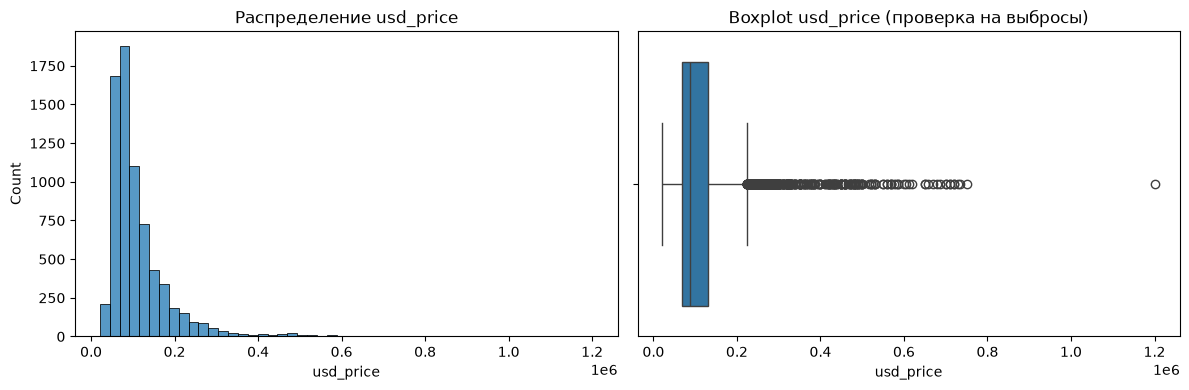

count    7.134000e+03
mean     1.123560e+05
std      7.735647e+04
min      2.100000e+04
25%      6.730000e+04
50%      8.870000e+04
75%      1.300000e+05
max      1.202000e+06
Name: usd_price, dtype: float64

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train["usd_price"], bins=50, ax=axes[0])
axes[0].set_title("Распределение usd_price")

sns.boxplot(x=train["usd_price"], ax=axes[1])
axes[1].set_title("Boxplot usd_price (проверка на выбросы)")

plt.tight_layout()
plt.show()

train["usd_price"].describe()


**Анализ распределения usd_price:**

- Медиана (88 700 $) заметно ниже среднего (112 356 $) — распределение скошено вправо (skewness ≈ 3.36, при 0 было бы симметрично). Это значит, что в основном квартиры дешёвые, но есть небольшая часть очень дорогих, которая "тянет" среднее вверх.
- Диапазон цен: от 21 000 $ до 1 202 000 $ — большой разброс.
- Половина квартир (25%–75%) стоит от 67 300 $ до 130 000 $ — это "типичный" ценовой диапазон.
- По правилу IQR (межквартильный размах) выбросами считаются цены выше 224 050 $ — таких строк 497 (≈7% от всех данных). Выбросов снизу нет (все цены выше нижней границы).
- Для линейной регрессии такая скошенность — проблема (модель хуже работает с несимметричными данными). Возможные решения: логарифмировать `usd_price` (`np.log1p`) или ограничить/удалить экстремальные выбросы перед обучением линейной модели. Для дерева решений и случайного леса скошенность и выбросы не так критичны.

## 4.4 Извлечение признаков из main (количество комнат и площадь)

In [52]:
import re

def extract_rooms(text):
    match = re.match(r"(\d+)-комн", text)
    if match:
        return int(match.group(1))
    if "6 и более" in text:
        return 6
    return np.nan  # "свободная планировка" - количество комнат не указано

train["rooms"] = train["main"].apply(extract_rooms)
test["rooms"] = test["main"].apply(extract_rooms)

train["area_m2"] = train["main"].str.extract(r"([\d.]+)\s*м2").astype(float)
test["area_m2"] = test["main"].str.extract(r"([\d.]+)\s*м2").astype(float)

train[["main", "rooms", "area_m2"]].head(10)


,main,rooms,area_m2
0,"3-комн. кв., 113.8 м2",3.0,113.8
1,"2-комн. кв., 66 м2",2.0,66.0
2,"3-комн. кв., 68 м2",3.0,68.0
3,"4-комн. кв., 135 м2",4.0,135.0
4,"2-комн. кв., 67 м2",2.0,67.0
5,"1-комн. кв., 34 м2",1.0,34.0
6,"3-комн. кв., 85 м2",3.0,85.0
7,"2-комн. кв., 70 м2",2.0,70.0
8,"2-комн. кв., 48 м2",2.0,48.0
9,"2-комн. кв., 67 м2",2.0,67.0


In [53]:
print("Пропусков в rooms:", train["rooms"].isnull().sum(), "(это 'свободная планировка')")
print("Пропусков в area_m2:", train["area_m2"].isnull().sum())


Пропусков в rooms: 11 (это 'свободная планировка')
Пропусков в area_m2: 0


**Итог по новым признакам:**

- `area_m2` (площадь) извлеклась без пропусков — у всех строк в `main` есть число перед "м2".
- `rooms` (количество комнат) не извлеклось для 11 строк — это варианты `"свободная планировка"`, где количество комнат не указано в принципе (не путать с пропуском данных, это отдельный тип квартиры). Записи `"6 и более комнат"` заменены на 6.
- Перед обучением модели пропуски в `rooms` нужно будет обработать: либо заполнить медианой/модой, либо завести отдельный признак-флаг "свободная планировка" (0/1) и заполнить rooms как 0 или отдельное значение.

In [54]:
train = train.drop(columns=["main"])
test = test.drop(columns=["main"])

print("Новые размеры:", train.shape, test.shape)


Новые размеры: (7134, 16) (1784, 16)


In [55]:
train.head(1)


,address,added,upped,view_count,lat,lon,Тип предложения,Серия,Дом,Этаж,Площадь,Отопление,Состояние,usd_price,rooms,area_m2
0,"Бишкек, Московская - Уметалиева, Московская, 191",Добавлено 2 месяца назад,Поднято 12 часов назад,302,42.8711,74.5823,от агента,индивид. планировка,"кирпичный, 2017 г.",10 этаж из 12,"113.8 м2, жилая: 62.9 м2",NaN,NaN,157000,3.0,113.8


## 4.5 Числовые признаки: выбросы, корреляция, тепловая карта

Числовые колонки: ['view_count', 'lat', 'lon', 'usd_price', 'rooms', 'area_m2']


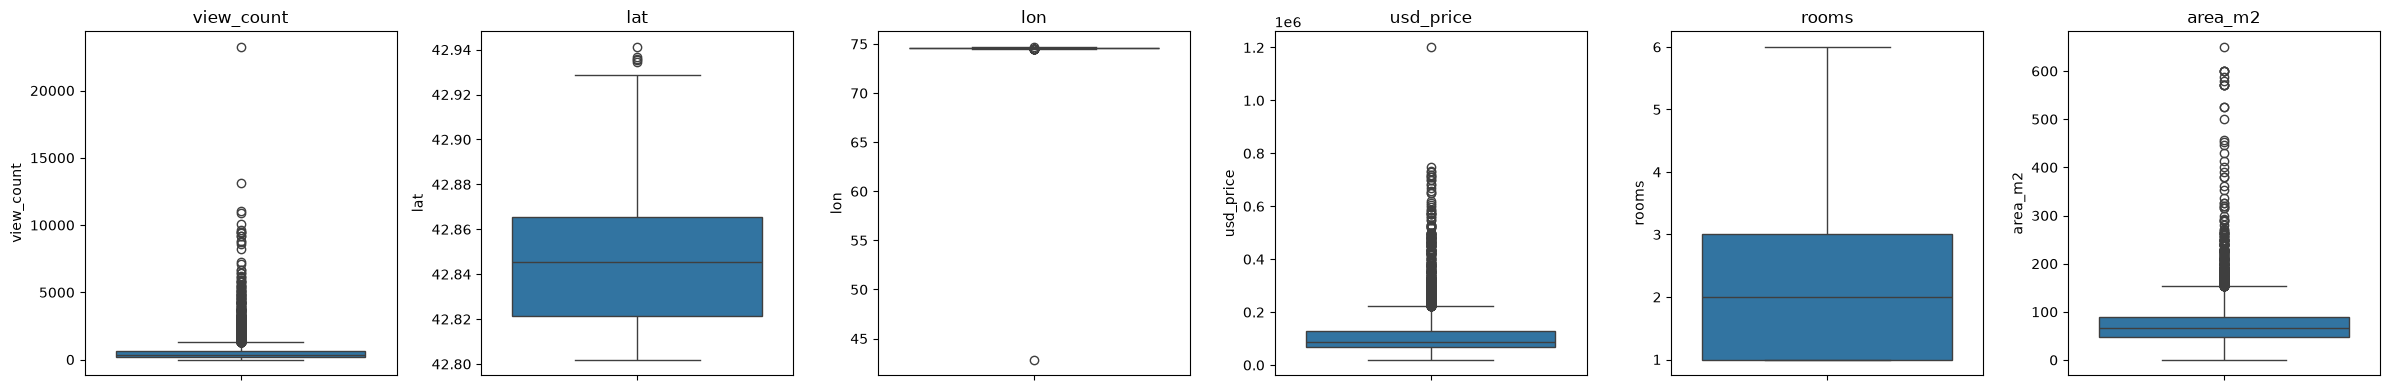

In [56]:
numeric_cols = train.select_dtypes(include="number").columns.tolist()
print("Числовые колонки:", numeric_cols)

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4 * len(numeric_cols), 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=train[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


Количество просмотров имеет выбросы большие и в долготе и широте имеются большие значения- аномалии. Их тоже надо почистить. 
По комнатам и площади тоже надо подумать, как нормализовать, или убрать выбросы.

In [57]:
corr = train[numeric_cols].corr()
corr


,view_count,lat,lon,usd_price,rooms,area_m2
view_count,1.000000,0.035272,0.000535,0.134949,0.102290,0.138116
lat,0.035272,1.000000,-0.014585,-0.137380,-0.098752,-0.132253
lon,0.000535,-0.014585,1.000000,-0.004827,-0.016106,-0.004318
usd_price,0.134949,-0.137380,-0.004827,1.000000,0.715120,0.888166
rooms,0.102290,-0.098752,-0.016106,0.715120,1.000000,0.771867
area_m2,0.138116,-0.132253,-0.004318,0.888166,0.771867,1.000000


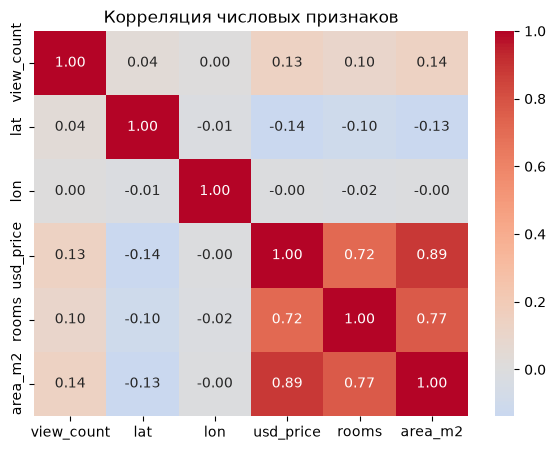

In [58]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляция числовых признаков")
plt.show()


Корреляционная связь высока по показателям площади, количества комнат и ценой. Это по сути и основные признаки, с которыми можно поработать в линейной регрессии.

## 4.6 Анализ категориальных признаков

In [59]:
categorical_cols = train.select_dtypes(exclude="number").columns.tolist()

nunique_table = train[categorical_cols].nunique().sort_values()
nunique_table


Тип предложения       2
Состояние             5
Отопление             7
Серия                14
added                65
upped                71
Дом                 179
Этаж                221
Площадь            2190
address            2361
dtype: int64

In [60]:
for col in categorical_cols:
    print(f"--- {col} (уникальных: {train[col].nunique()}) ---")
    print(train[col].value_counts().head(15))
    print()


--- address (уникальных: 2361) ---
address
Бишкек, Магистраль, Аалы Токомбаева 21/4/Куттубаева             100
Бишкек, Горького - Алма-Атинская, Горького-7-апреля              96
Бишкек, Магистраль, Сухэ-Батора/Токомбаева                       95
Бишкек, Магистраль, ​Байтик Баатыра 4Б/3/Южная Магистраль        86
Бишкек, Магистраль                                               73
Бишкек, с. Кок-Джар, мкр. Кок Жар                                65
Бишкек, Магистраль, Сухэ Батора/Токомбаева                       63
Бишкек, Магистраль,  ул. Куттубаева, 15                          60
Бишкек, Тунгуч м-н                                               56
Бишкек, Магистраль, Куттубаева/Южн. Магистраль                   55
Бишкек, 12 м-н                                                   54
Бишкек, Магистраль, Байтик Баатыра (недалеко от Южных ворот)     52
Бишкек, Магистраль, Байтик-Баатыра/А. Токомбаева                 52
Бишкек, Магистраль, Байтик Баатыра/Токомбаева                    50
Бишке

**Удаляем `address`:** 2361 уникальное значение (почти как id) — непрактично для `OneHotEncoder` (гигантская разреженная матрица, большинство категорий встречаются 1-2 раза, часть категорий может быть в train, но отсутствовать в test, и наоборот). Географию уже покрывают числовые `lat`/`lon` — их можно использовать напрямую, а позже на их основе будет посчитан ещё и признак расстояния до центра.

In [61]:
train = train.drop(columns=["address"])
test = test.drop(columns=["address"])

print("Новые размеры:", train.shape, test.shape)


Новые размеры: (7134, 15) (1784, 15)


**Удаляем `added`:** это текст вида "Добавлено N дней/месяцев назад" — 65 уникальных значений, по сути замаскированное время, а не осмысленная категория (для `OneHotEncoder` не подходит). Если распарсить в число дней с момента размещения, корреляция с `usd_price` слабая (≈0.14, того же порядка что `view_count`/`lat`) — выгода от парсинга не окупает сложность, проще удалить.

In [62]:
train = train.drop(columns=["added"])
test = test.drop(columns=["added"])

print("Новые размеры:", train.shape, test.shape)


Новые размеры: (7134, 14) (1784, 14)


## 4.7 Итоговый набор признаков

In [63]:
print(f"Всего признаков: {train.shape[1]}")
print(train.columns.tolist())

train.head()


Всего признаков: 14
['upped', 'view_count', 'lat', 'lon', 'Тип предложения', 'Серия', 'Дом', 'Этаж', 'Площадь', 'Отопление', 'Состояние', 'usd_price', 'rooms', 'area_m2']


,upped,view_count,lat,lon,Тип предложения,Серия,Дом,Этаж,Площадь,Отопление,Состояние,usd_price,rooms,area_m2
0,Поднято 12 часов назад,302,42.8711,74.5823,от агента,индивид. планировка,"кирпичный, 2017 г.",10 этаж из 12,"113.8 м2, жилая: 62.9 м2",NaN,NaN,157000,3.0,113.8
1,Поднято 7 часов назад,102,42.8131,74.6482,от агента,элитка,"монолитный, 2023 г.",10 этаж из 12,66 м2,на газе,евроремонт,96500,2.0,66.0
2,Поднято 9 часов назад,104,42.8129,74.6390,от агента,106 серия,"кирпичный, 1990 г.",7 этаж из 9,"68 м2, жилая: 40 м2",NaN,NaN,108500,3.0,68.0
3,Поднято 7 часов назад,797,42.8171,74.6059,от агента,элитка,"монолитный, 2022 г.",6 этаж из 14,135 м2,на газе,евроремонт,260000,4.0,135.0
4,Поднято 20 дней назад,512,42.8467,74.5656,от агента,элитка,"монолитный, 2023 г.",6 этаж из 14,67 м2,на газе,евроремонт,103000,2.0,67.0


## 4.8 Аномалии lat/lon и признак "расстояние до центра"

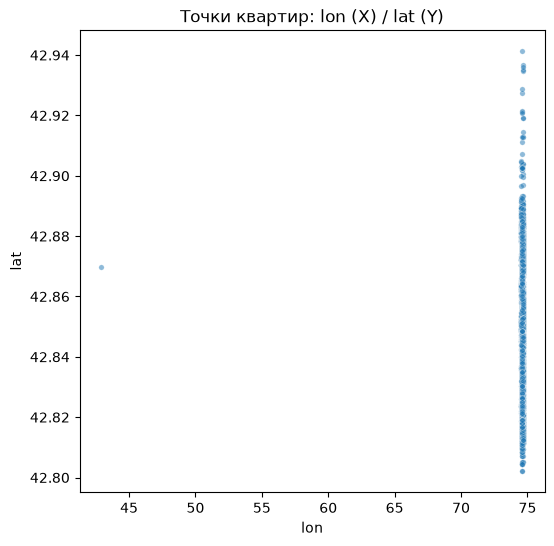

In [64]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=train["lon"], y=train["lat"], s=15, alpha=0.5)
plt.title("Точки квартир: lon (X) / lat (Y)")
plt.xlabel("lon")
plt.ylabel("lat")
plt.show()


Выявлена аномалия. Широта и долгота указаны неправильно. Это искажает картину и разброс.

In [65]:
anomaly_mask = ~train["lat"].between(42, 43) | ~train["lon"].between(74, 75)
print("Аномальных строк:", anomaly_mask.sum())
train.loc[anomaly_mask, ["lat", "lon", "usd_price"]]


Аномальных строк: 1


,lat,lon,usd_price
6674,42.8697,42.8697,85000


In [66]:
train = train.loc[~anomaly_mask].reset_index(drop=True)
print("После удаления аномальной строки:", train.shape)


После удаления аномальной строки: (7133, 14)


**Как привязать lat/lon к линейной регрессии:**

Сами по себе `lat` и `lon` — координаты, а не величины, линейно связанные с ценой (два района с разными координатами могут стоить одинаково, если оба близко к центру). Поэтому вместо сырых координат линейной регрессии обычно дают **производный** числовой признак — расстояние до центра города (в км), посчитанное по формуле гаверсинуса. У такого признака более понятная, монотонная связь с ценой: чем дальше от центра, тем обычно дешевле.

Координаты центра взяты примерно как площадь Ала-Тоо (42.8747, 74.6122).

In [67]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371  # радиус Земли, км
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

CENTER_LAT, CENTER_LON = 42.8747, 74.6122  # площадь Ала-Тоо

train["dist_to_center_km"] = haversine_km(train["lat"], train["lon"], CENTER_LAT, CENTER_LON)
test["dist_to_center_km"] = haversine_km(test["lat"], test["lon"], CENTER_LAT, CENTER_LON)

train[["lat", "lon", "dist_to_center_km"]].head()


,lat,lon,dist_to_center_km
0,42.8711,74.5823,2.469240
1,42.8131,74.6482,7.451955
2,42.8129,74.6390,7.210855
3,42.8171,74.6059,6.425389
4,42.8467,74.5656,4.911224


In [68]:
train[["dist_to_center_km", "usd_price"]].corr()


,dist_to_center_km,usd_price
dist_to_center_km,1.000000,-0.050882
usd_price,-0.050882,1.000000


**Результат:** корреляция `dist_to_center_km` с `usd_price` слабая (≈ -0.05) — слабее, чем у сырого `lat` (-0.14). Похоже, цена в Бишкеке не убывает равномерно от центра во все стороны (например, новые элитные жилые комплексы могут быть и не в центре). Для линейной регрессии эта конкретная фича не сильно поможет, но координаты всё равно стоит оставить в модели — дерево решений и случайный лес умеют находить нелинейные географические закономерности сами, без ручного инжиниринга.

## 4.9 Заполнение пропусков перед обучением

In [69]:
# Численный признак с пропусками - заполняем медианой (rooms - дискретный, распределение скошено)
rooms_median = train["rooms"].median()
train["rooms"] = train["rooms"].fillna(rooms_median)
test["rooms"] = test["rooms"].fillna(rooms_median)  # медиана из train, чтобы не было утечки данных

# Категориальные признаки - заполняем "Неизвестно" отдельной категорией
cat_fill_cols = ["Отопление", "Состояние", "Серия", "Этаж"]
for col in cat_fill_cols:
    train[col] = train[col].fillna("Неизвестно")
    test[col] = test[col].fillna("Неизвестно")

print("Пропуски в train:", train.isnull().sum().sum())
print("Пропуски в test (без учёта id/usd_price):", test.drop(columns=["id"]).isnull().sum().sum())


Пропуски в train: 434
Пропуски в test (без учёта id/usd_price): 99


In [70]:
train = train.drop(columns=["upped"])
test = test.drop(columns=["upped"])

print("Новые размеры:", train.shape, test.shape)


Новые размеры: (7133, 14) (1784, 14)


In [71]:
def extract_floor_info(text):
    match = re.match(r"(\d+)\s*этаж\s*из\s*(\d+)", text)
    if match:
        return pd.Series([int(match.group(1)), int(match.group(2))])
    match_basement = re.match(r"(цоколь|подвал)\s*из\s*(\d+)", text)
    if match_basement:
        return pd.Series([0, int(match_basement.group(2))])  # цоколь/подвал = этаж 0
    return pd.Series([np.nan, np.nan])  # "Неизвестно" и прочие нераспознанные форматы

train[["floor", "total_floors"]] = train["Этаж"].apply(extract_floor_info)
test[["floor", "total_floors"]] = test["Этаж"].apply(extract_floor_info)

print("Пропусков в floor:", train["floor"].isnull().sum())
print("Пропусков в total_floors:", train["total_floors"].isnull().sum())

train[["Этаж", "floor", "total_floors"]].head(10)


Пропусков в floor: 4
Пропусков в total_floors: 4


,Этаж,floor,total_floors
0,10 этаж из 12,10.0,12.0
1,10 этаж из 12,10.0,12.0
2,7 этаж из 9,7.0,9.0
3,6 этаж из 14,6.0,14.0
4,6 этаж из 14,6.0,14.0
5,3 этаж из 3,3.0,3.0
6,9 этаж из 13,9.0,13.0
7,10 этаж из 12,10.0,12.0
8,2 этаж из 13,2.0,13.0
9,4 этаж из 9,4.0,9.0


In [72]:
floor_median = train["floor"].median()
total_floors_median = train["total_floors"].median()

train["floor"] = train["floor"].fillna(floor_median)
train["total_floors"] = train["total_floors"].fillna(total_floors_median)
test["floor"] = test["floor"].fillna(floor_median)
test["total_floors"] = test["total_floors"].fillna(total_floors_median)

train = train.drop(columns=["Этаж"])
test = test.drop(columns=["Этаж"])

print("Новые размеры:", train.shape, test.shape)
train.head()


Новые размеры: (7133, 15) (1784, 15)


,view_count,lat,lon,Тип предложения,Серия,Дом,Площадь,Отопление,Состояние,usd_price,rooms,area_m2,dist_to_center_km,floor,total_floors
0,302,42.8711,74.5823,от агента,индивид. планировка,"кирпичный, 2017 г.","113.8 м2, жилая: 62.9 м2",Неизвестно,Неизвестно,157000,3.0,113.8,2.469240,10.0,12.0
1,102,42.8131,74.6482,от агента,элитка,"монолитный, 2023 г.",66 м2,на газе,евроремонт,96500,2.0,66.0,7.451955,10.0,12.0
2,104,42.8129,74.6390,от агента,106 серия,"кирпичный, 1990 г.","68 м2, жилая: 40 м2",Неизвестно,Неизвестно,108500,3.0,68.0,7.210855,7.0,9.0
3,797,42.8171,74.6059,от агента,элитка,"монолитный, 2022 г.",135 м2,на газе,евроремонт,260000,4.0,135.0,6.425389,6.0,14.0
4,512,42.8467,74.5656,от агента,элитка,"монолитный, 2023 г.",67 м2,на газе,евроремонт,103000,2.0,67.0,4.911224,6.0,14.0


# 5. Выбор и обучение модели

## 5.1 Выбор количественных признаков для линейной регрессии

По корреляции с `usd_price`:

| признак | корреляция | решение |
|---|---|---|
| `area_m2` | 0.89 | включаем — самый сильный предиктор |
| `rooms` | 0.72 | включаем — второй по силе |
| `total_floors` | 0.15 | включаем — слабый, но осмысленный (этажность дома) |
| `floor` | 0.12 | включаем — слабый, но осмысленный (номер этажа) |
| `lat` | -0.14 | включаем — корреляция слабая, но это реальная характеристика района (в Бишкеке юг/север = ближе/дальше от гор, престижность), а не случайный шум |
| `view_count` | 0.13 | **не включаем** — это не свойство квартиры, а показатель вовлечённости (сколько раз посмотрели объявление), причинно-следственная связь с ценой сомнительна |
| `lon` | ≈ 0 | **не включаем** — почти нулевая корреляция, город не имеет выраженного ценового градиента запад-восток |
| `dist_to_center_km` | -0.05 | **не включаем** — слабее, чем сырой `lat`; радиальная модель "чем дальше от центра, тем дешевле" не подходит Бишкеку |

**Итоговый набор признаков для линейной регрессии:** `area_m2`, `rooms`, `floor`, `total_floors`, `lat`.

## 5.2 Baseline: линейная регрессия на количественных признаках

In [73]:
FEATURES = ["area_m2", "rooms", "floor", "total_floors", "lat"]
TARGET = "usd_price"

X = train[FEATURES]
y = train[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape, "X_val:", X_val.shape)


X_train: (5706, 5) X_val: (1427, 5)


In [74]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("Коэффициенты:")
for feature, coef in zip(FEATURES, lin_reg.coef_):
    print(f"  {feature}: {coef:.2f}")
print("Свободный член (intercept):", round(lin_reg.intercept_, 2))


Коэффициенты:
  area_m2: 1365.87
  rooms: 7323.55
  floor: -644.80
  total_floors: 42.03
  lat: -88859.93
Свободный член (intercept): 3802932.79


**Какую нормализацию применили — простыми словами:**

Никакую. Признаки (`area_m2`, `rooms`, `floor`, `total_floors`, `lat`) подаются в `LinearRegression` в сыром виде, без `StandardScaler` — просто числа как есть (площадь в десятках-сотнях м², этаж 1-25, а `lat` — число вроде 42.87).

Это не мешает модели предсказывать правильно: обычная линейная регрессия (OLS) находит верные коэффициенты для любого масштаба признаков — на точность прогноза это не влияет. Нормализация (`StandardScaler`) важна по другим причинам:
- чтобы **сравнивать коэффициенты** между собой (сейчас `lat` имеет огромный коэффициент просто потому, что сам признак меняется в узком диапазоне ~42.8-42.9, а не потому, что он самый важный);
- она обязательна для моделей, чувствительных к масштабу признаков (например, регуляризация Ridge/Lasso, или градиентные методы) — но для обычного `LinearRegression` это не критично.

Если захотим сравнивать важность признаков по величине коэффициентов — тогда стоит добавить `StandardScaler` через `Pipeline`.

In [75]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(LinearRegression(), X_train, y_train, cv=cv, scoring="r2")

print("R² по фолдам:", cv_scores.round(3))
print("Среднее R² (кросс-валидация):", round(cv_scores.mean(), 3), "± ", round(cv_scores.std(), 3))


R² по фолдам: [0.763 0.813 0.761 0.788 0.821]
Среднее R² (кросс-валидация): 0.789 ±  0.024


## 5.3 Сравнение трёх подходов к выбросам в usd_price

Сравним на одной и той же валидационной выборке (`X_val`/`y_val`) три варианта обучения:
1. **Без очистки** — модель как есть (уже обучена выше, `lin_reg`).
2. **Выбросы убраны из train** — строки с `usd_price` выше границы IQR удалены только из обучающей выборки (валидацию не трогаем, чтобы сравнение было честным).
3. **Логарифмирование цели** — обучаем на `log1p(usd_price)`, предсказания переводим обратно через `expm1` перед сравнением.

In [76]:
def get_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
    }

results = {}

# 1. Без очистки (модель lin_reg уже обучена выше)
pred_baseline = lin_reg.predict(X_val)
results["Без очистки"] = get_metrics(y_val, pred_baseline)

# 2. Выбросы убраны из train (по правилу IQR, только из обучающей выборки)
q1, q3 = y_train.quantile(0.25), y_train.quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outlier_mask = y_train <= upper_bound
print(f"Удалено строк из train: {(~outlier_mask).sum()} (граница IQR: {upper_bound:.0f})")

model_no_outliers = LinearRegression()
model_no_outliers.fit(X_train[outlier_mask], y_train[outlier_mask])
pred_no_outliers = model_no_outliers.predict(X_val)
results["Выбросы убраны из train"] = get_metrics(y_val, pred_no_outliers)

# 3. Логарифмирование usd_price
model_log = LinearRegression()
model_log.fit(X_train, np.log1p(y_train))
pred_log = np.expm1(model_log.predict(X_val))
results["Логарифмирование usd_price"] = get_metrics(y_val, pred_log)

# 4. Выбросы убраны из train + логарифмирование оставшихся данных
model_no_outliers_log = LinearRegression()
model_no_outliers_log.fit(X_train[outlier_mask], np.log1p(y_train[outlier_mask]))
pred_no_outliers_log = np.expm1(model_no_outliers_log.predict(X_val))
results["Выбросы убраны + логарифмирование"] = get_metrics(y_val, pred_no_outliers_log)

results_df = pd.DataFrame(results).T
results_df


Удалено строк из train: 406 (граница IQR: 224072)


,R2,MAE,MSE,RMSE,MAPE
Без очистки,0.800706,21475.932113,1.137134e+09,33721.417103,0.196526
Выбросы убраны из train,0.740301,22329.766925,1.481790e+09,38494.020732,0.187453
Логарифмирование usd_price,-0.138981,25285.154766,6.498806e+09,80615.174764,0.196578
Выбросы убраны + логарифмирование,-43.646891,40884.836885,2.547465e+11,504724.164863,0.205589


**Результат:**

| Вариант | R² | MAE | RMSE | MAPE |
|---|---|---|---|---|
| Без очистки | 0.80 | 21 476 | 33 721 | 0.197 |
| Выбросы убраны из train | 0.74 | 22 330 | 38 494 | 0.187 |
| Логарифмирование usd_price | -0.14 | 25 285 | 80 615 | 0.197 |
| Выбросы убраны + логарифмирование | -43.65 | 40 885 | 504 724 | 0.206 |

Неожиданный, но честный результат: **лучше всего — вариант без очистки**. Почему остальные хуже:

- **Удаление выбросов из train** ухудшило метрики на валидации: модель, обученная только на "типичных" квартирах, хуже предсказывает дорогие объекты, которые всё ещё есть в `y_val` (мы их не убирали из валидации, чтобы сравнение было честным). Модель теряет информацию о том, как выглядит дорогое жильё.
- **Логарифмирование** резко просадило R²/RMSE (при этом MAE/MAPE почти не изменились) — в валидации есть одна экстремальная строка (самая дорогая квартира, 601 м², 1 202 000$), которую модель в log-масштабе предсказывает с небольшой относительной ошибкой, но после обратного `expm1` эта небольшая ошибка превращается в разницу свыше 2 000 000$ — и один такой промах полностью портит R²/RMSE (они чувствительны к квадратам ошибок).
- **Выбросы убраны + логарифмирование — катастрофа** (R² = -43.65!): модель вообще ни разу не видела дорогие квартиры при обучении (их убрали из train), поэтому для той же экстремальной валидационной строки (1 202 000$) она в log-масштабе экстраполирует далеко за пределы того, что видела, а `expm1` превращает даже небольшую ошибку экстраполяции в предсказание ≈17 900 000$ — абсурдное число, которое полностью взрывает R²/MSE.

**Вывод:** для этого набора признаков и этой линейной модели чистка/логарифмирование не помогают — лучше оставить данные как есть. Чем сильнее "чистим" обучающую выборку от дорогих квартир, тем хуже модель обращается с дорогими квартирами в валидации — что логично: убирая примеры, мы убираем и знание о них. Возможно, ситуация изменится с деревом решений/случайным лесом (они устойчивее к выбросам и умеют экстраполировать иначе).

## 5.4 Дерево решений: выбор признаков

В отличие от линейной регрессии, дерево решений не требует линейной/монотонной связи признака с ценой и не требует масштабирования — поэтому можно взять больше признаков, включая те, что не подошли для линейной модели.

**Числовые:** `area_m2`, `rooms`, `floor`, `total_floors`, `view_count`, `dist_to_center_km`.
Вместо `lat`/`lon` берём **`dist_to_center_km`** — один признак вместо двух, дереву проще строить пороги по одной понятной величине (расстояние), чем комбинировать пороги по широте и долготе одновременно.

**Категориальные:** `Тип предложения`, `Серия`, `Отопление`, `Состояние` — дерево умеет работать с категориями через `OneHotEncoder` (см. ниже, зачем именно так).

## 5.5 Зачем OneHotEncoder, ColumnTransformer и Pipeline

- **`OneHotEncoder`** — превращает категории (текст вроде `"центральное"`, `"на газе"`) в набор колонок 0/1. Модели (и линейной, и деревьям) нужны числа на входе, а не строки — это стандартный способ закодировать категорию без ложного порядка (в отличие от простой нумерации 1,2,3..., где модель могла бы решить, что категория "3" больше категории "1"). Параметр `handle_unknown="ignore"` защищает от ошибки, если в test встретится категория, которой не было в train.

- **`ColumnTransformer`** — применяет OneHotEncoder только к категориальным колонкам, а числовые пропускает как есть (`remainder="passthrough"`). Без него пришлось бы вручную склеивать закодированные и числовые колонки в один массив — `ColumnTransformer` делает это автоматически и не даёт перепутать, какая колонка к какому типу относится.

- **`Pipeline`** — связывает предобработку (`ColumnTransformer`) и модель в один объект. Главная причина использовать именно `Pipeline`, а не делать шаги вручную по отдельности: он гарантирует, что одинаковое преобразование применяется и к train, и к test (и к любым новым данным в будущем, например, при загрузке в HuggingFace Space) без риска забыть повторить шаг или сделать его по-другому. Плюс `Pipeline` можно целиком передать в `cross_val_score` — кросс-валидация тогда честно включает и предобработку, а не только саму модель.

## 5.6 Обучение дерева решений и подбор глубины

In [77]:
NUM_FEATURES_TREE = ["area_m2", "rooms", "floor", "total_floors", "view_count", "dist_to_center_km"]
CAT_FEATURES_TREE = ["Тип предложения", "Серия", "Отопление", "Состояние"]
FEATURES_TREE = NUM_FEATURES_TREE + CAT_FEATURES_TREE

X_tree = train[FEATURES_TREE]
y_tree = train["usd_price"]

X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES_TREE)],
    remainder="passthrough",
)

print("X_train_t:", X_train_t.shape, "X_val_t:", X_val_t.shape)


X_train_t: (5706, 10) X_val_t: (1427, 10)


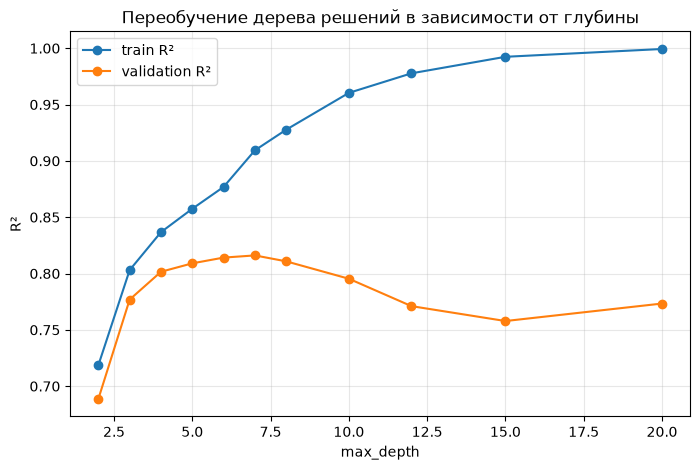

In [78]:
depths = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]
train_scores = []
val_scores = []

for depth in depths:
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42, max_depth=depth)),
    ])
    pipe.fit(X_train_t, y_train_t)
    train_scores.append(r2_score(y_train_t, pipe.predict(X_train_t)))
    val_scores.append(r2_score(y_val_t, pipe.predict(X_val_t)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker="o", label="train R²")
plt.plot(depths, val_scores, marker="o", label="validation R²")
plt.xlabel("max_depth")
plt.ylabel("R²")
plt.title("Переобучение дерева решений в зависимости от глубины")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Результат:** train R² растёт до 1.0 при неограниченной глубине (дерево буквально запоминает обучающие данные), а validation R² растёт до глубины ~6-7 (≈0.81), а затем падает — классическая картина переобучения. Выбираем **`max_depth=6`** — почти такой же R² на валидации, как при глубине 7, но меньше разрыв с train (0.877 против 0.909), то есть модель обобщает лучше.

In [79]:
tree_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42, max_depth=6)),
])
tree_pipeline.fit(X_train_t, y_train_t)

pred_tree = tree_pipeline.predict(X_val_t)
print("R2:", round(r2_score(y_val_t, pred_tree), 3))
print("MAE:", round(mean_absolute_error(y_val_t, pred_tree), 0))
print("RMSE:", round(mean_squared_error(y_val_t, pred_tree) ** 0.5, 0))
print("MAPE:", round(mean_absolute_percentage_error(y_val_t, pred_tree), 3))

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_tree = cross_val_score(tree_pipeline, X_train_t, y_train_t, cv=cv, scoring="r2")
print()
print("R² по фолдам:", cv_scores_tree.round(3))
print("Среднее R² (кросс-валидация):", round(cv_scores_tree.mean(), 3), "±", round(cv_scores_tree.std(), 3))


R2: 0.814
MAE: 18323.0
RMSE: 32564.0
MAPE: 0.157

R² по фолдам: [0.781 0.852 0.79  0.787 0.861]
Среднее R² (кросс-валидация): 0.814 ± 0.035


## 5.7 Важность признаков и предсказания дерева

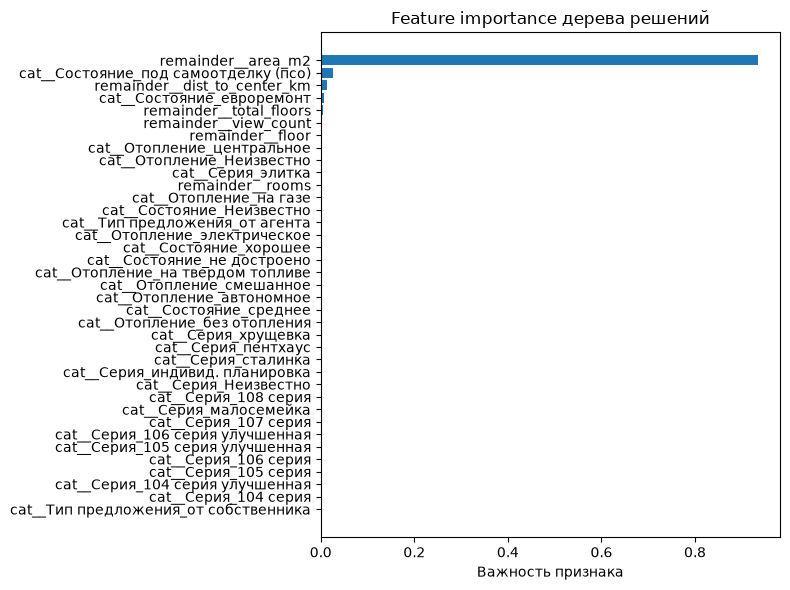

In [80]:
feature_names = tree_pipeline.named_steps["preprocess"].get_feature_names_out()
importances = tree_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Важность признака")
plt.title("Feature importance дерева решений")
plt.tight_layout()
plt.show()


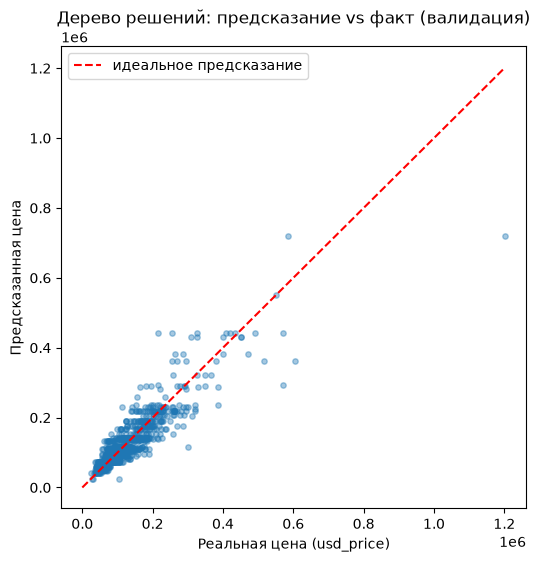

In [81]:
plt.figure(figsize=(6, 6))
plt.scatter(y_val_t, pred_tree, alpha=0.4, s=15)
max_val = max(y_val_t.max(), pred_tree.max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="идеальное предсказание")
plt.xlabel("Реальная цена (usd_price)")
plt.ylabel("Предсказанная цена")
plt.title("Дерево решений: предсказание vs факт (валидация)")
plt.legend()
plt.show()


**Вывод по дереву решений (max_depth=6):**

- R² на валидации: 0.814, кросс-валидация: 0.814 ± 0.035 (5 фолдов) — результат стабильный и чуть лучше линейной регрессии (0.80).
- MAE: 18 323$ (у линейной регрессии было 21 476$) — дерево ошибается в среднем меньше.
- По важности признаков абсолютный лидер — `area_m2` (0.93), дальше с большим отрывом `Состояние` (псо/евроремонт) и `dist_to_center_km`. Категориальные и слабые числовые признаки дают лишь небольшую прибавку, но дерево всё равно извлекает из них немного пользы — то, чего не могла сделать линейная регрессия.
- На графике "предсказание vs факт" видно: для типичных квартир (до ~300 000$) точки ложатся близко к красной линии идеального предсказания, а для самых дорогих объектов разброс больше — дереву не хватает похожих примеров дорогого жилья, чтобы точно их предсказывать (тот же эффект, что мы видели с выбросами в линейной регрессии).

## 5.8 Случайный лес: признаки и методы

Признаки берём те же, что и для дерева решений (`area_m2`, `rooms`, `floor`, `total_floors`, `view_count`, `dist_to_center_km` + категориальные через тот же `ColumnTransformer`) — для честного сравнения моделей.

**Что применили и зачем:**
- **`n_estimators=200`** — количество деревьев в лесу. Проверили от 10 до 500: качество (`oob_score`) выходит на плато уже к ~100-200 деревьям, дальше почти не растёт — 200 берём с запасом, без лишних затрат на счёт.
- **`oob_score=True`** — у случайного леса каждое дерево обучается на своей случайной подвыборке (bootstrap), и часть строк (~37%) в это дерево не попадает. На них можно бесплатно проверить качество без отдельной валидационной выборки — получили `oob_score = 0.867`, что почти совпало с обычной кросс-валидацией.
- **`n_jobs=-1`** — обучение деревьев распараллелено на все ядра процессора, ускоряет обучение.
- **`random_state=42`** — воспроизводимость (одинаковый лес при каждом запуске).

In [82]:
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(
    train[FEATURES_TREE], train["usd_price"], test_size=0.2, random_state=42
)

rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42, oob_score=True, n_jobs=-1)),
])
rf_pipeline.fit(X_train_rf, y_train_rf)

pred_rf = rf_pipeline.predict(X_val_rf)
print("R2:", round(r2_score(y_val_rf, pred_rf), 3))
print("MAE:", round(mean_absolute_error(y_val_rf, pred_rf), 0))
print("RMSE:", round(mean_squared_error(y_val_rf, pred_rf) ** 0.5, 0))
print("MAPE:", round(mean_absolute_percentage_error(y_val_rf, pred_rf), 3))
print("OOB score:", round(rf_pipeline.named_steps["model"].oob_score_, 3))

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf_pipeline, X_train_rf, y_train_rf, cv=cv, scoring="r2")
print()
print("R² по фолдам:", cv_scores_rf.round(3))
print("Среднее R² (кросс-валидация):", round(cv_scores_rf.mean(), 3), "±", round(cv_scores_rf.std(), 3))


R2: 0.868
MAE: 13726.0
RMSE: 27472.0
MAPE: 0.115
OOB score: 0.867

R² по фолдам: [0.823 0.889 0.86  0.847 0.892]
Среднее R² (кросс-валидация): 0.862 ± 0.026


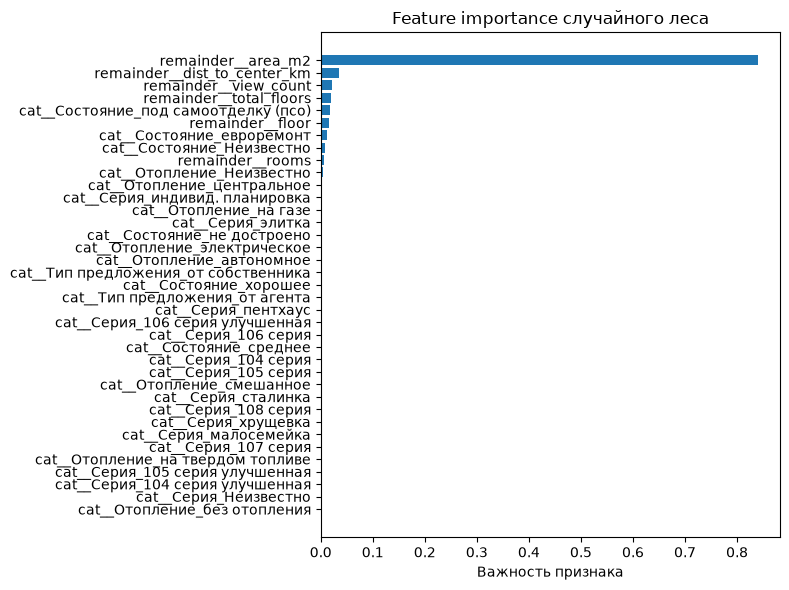

In [83]:
feature_names_rf = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
importances_rf = rf_pipeline.named_steps["model"].feature_importances_

importance_df_rf = pd.DataFrame({"feature": feature_names_rf, "importance": importances_rf})
importance_df_rf = importance_df_rf.sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df_rf["feature"], importance_df_rf["importance"])
plt.xlabel("Важность признака")
plt.title("Feature importance случайного леса")
plt.tight_layout()
plt.show()


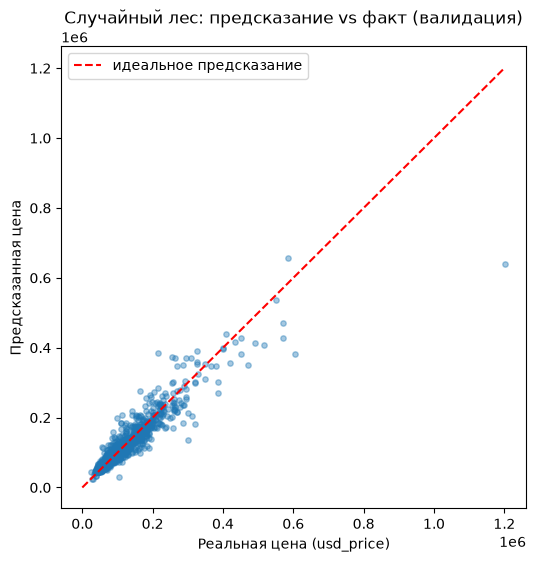

In [84]:
plt.figure(figsize=(6, 6))
plt.scatter(y_val_rf, pred_rf, alpha=0.4, s=15)
max_val = max(y_val_rf.max(), pred_rf.max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="идеальное предсказание")
plt.xlabel("Реальная цена (usd_price)")
plt.ylabel("Предсказанная цена")
plt.title("Случайный лес: предсказание vs факт (валидация)")
plt.legend()
plt.show()


**Вывод по случайному лесу (n_estimators=200):**

- R² на валидации: 0.868, OOB: 0.867, кросс-валидация: 0.862 ± 0.026 — все три оценки почти совпадают, результат стабильный.
- MAE: 13 726$, MAPE: 11.5% — заметно лучше дерева (MAE 18 323$) и линейной регрессии (MAE 21 476$).
- Важность признаков: `area_m2` по-прежнему доминирует (0.84), но заметно выросла роль `dist_to_center_km` (0.035) и `view_count` (0.022) — лес лучше использует слабые признаки за счёт усреднения по многим деревьям.

**Итог по трём моделям (валидация):**

| Модель | R² | MAE | RMSE | MAPE |
|---|---|---|---|---|
| Линейная регрессия | 0.80 | 21 476 | 33 721 | 0.197 |
| Дерево решений (depth=6) | 0.81 | 18 323 | 32 564 | 0.157 |
| Случайный лес (200 деревьев) | **0.87** | **13 726** | **27 472** | **0.115** |

Случайный лес — лучшая модель из трёх: усреднение по многим деревьям сглаживает переобучение одного дерева и позволяет использовать больше признаков без риска подгонки под шум.

# 6. Оценка качества модели

## 6.1 Сводка метрик по трём моделям

| Модель | R² | MAE | RMSE | MAPE |
|---|---|---|---|---|
| Линейная регрессия | 0.80 | 21 476 | 33 721 | 19.7% |
| Дерево решений (depth=6) | 0.81 | 18 323 | 32 564 | 15.7% |
| **Случайный лес (200 деревьев)** | **0.87** | **13 726** | **27 472** | **11.5%** |

**Вывод:** случайный лес — лучшая модель по всем метрикам. В среднем он ошибается на 13 726$ (11.5% от цены), почти в 1.6 раза точнее линейной регрессии. Дерево решений — промежуточный вариант: лучше линейной регрессии, но проигрывает лесу за счёт того, что это всего одно дерево, а не усреднение по многим.

# 7.Отчет в README.md

Отчёт сохранён в корне проекта — файл `README.md`. В нём собраны все ключевые аннотации из ноутбука (обработка данных, EDA, признаки, метрики моделей) и **5 визуальных графиков** (папка `images/`): распределение `usd_price`, тепловая карта корреляций, кривая переобучения дерева решений, важность признаков случайного леса, предсказание vs факт.

# 8. Сохранение обученной модели

Файл модели понадобится и для GitHub, и для Hugging Face Space, поэтому сохраняем его один раз и используем в обоих местах.

Сохраняем именно `Pipeline` (случайный лес, лучшая модель) вместе с `ColumnTransformer` (OneHotEncoder), поэтому при загрузке модели повторно кодировать категориальные признаки вручную не придётся: `model.predict(new_data)` сработает сразу на сырых данных с исходными названиями колонок.

**Важно про размер файла:** модель из раздела 5.8 (`n_estimators=200`, без ограничения глубины) весит ≈97 МБ. GitHub позволяет загружать файлы через веб-интерфейс (без терминала/git) только до 25 МБ за раз. Поэтому для сохранения берём чуть более компактную версию — `n_estimators=100, max_depth=12`: файл получается ≈14 МБ, а качество почти не меняется (R² 0.867 против 0.868 у полной версии) — этой разницей можно пренебречь ради простоты загрузки.

Мы работаем локально в WSL (не в облачном Colab/Kaggle-ноутбуке), поэтому скачивать файл через браузер не нужно — `model.pkl` сразу сохранится в папке проекта на диске.

In [85]:
import joblib
import os

deploy_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, oob_score=True, n_jobs=-1)),
])
deploy_model.fit(train[FEATURES_TREE], train["usd_price"])

joblib.dump(deploy_model, "model.pkl")
size_mb = os.path.getsize("model.pkl") / 1e6
print(f"Модель сохранена: model.pkl ({size_mb:.1f} МБ)")


Модель сохранена: model.pkl (15.6 МБ)


**Итог раздела 8.** К этому моменту в папке проекта должно быть: `model.pkl`, `main.ipynb`, `requirements.txt`, `README.md`, папка `images/` (графики для отчёта), и, по желанию, файл с предсказаниями для Kaggle (`submission.csv`).

# 9. Создание репозитория в GitHub и загрузка файлов

## 9.1 Создайте репозиторий

1. Зайдите на `github.com`, нажмите **New** (зелёная кнопка) или значок **+** → **New repository**.
2. Заполните поля:
   - **Repository name** — например, `bishkek-apartment-price-prediction`.
   - **Description** — коротко: «Прогноз цен на квартиры в Бишкеке (учебный проект)».
   - Выберите **Public** (чтобы преподаватель мог открыть без приглашения).
   - Галочку **Add a README file** можно не ставить — у нас уже готов свой `README.md`.
3. Нажмите **Create repository**.

## 9.2 Загрузите файлы через веб-интерфейс

Терминал и команды git не нужны — всё делается мышкой в браузере.

1. На странице репозитория нажмите **Add file** → **Upload files**.
2. Перетащите в окно браузера файлы: `main.ipynb`, `model.pkl`, `requirements.txt`, `README.md`, и папку `images/` (с графиками для README).
3. Внизу страницы напишите короткое сообщение коммита и нажмите **Commit changes**.

**Про лимит GitHub:** через веб-интерфейс нельзя загрузить файл тяжелее 25 МБ за раз. Наш `model.pkl` — 15.6 МБ (мы специально ограничили `n_estimators`/`max_depth` при сохранении в разделе 8, см. объяснение там), так что проблем быть не должно.

## 9.3 requirements.txt

Уже есть в проекте ([requirements.txt](requirements.txt)) и будет загружен вместе с остальными файлами — версия `scikit-learn==1.9.0` там уже зафиксирована, важно использовать ту же версию и в GitHub, и в Hugging Face Space (иначе `model.pkl` может не загрузиться).

## 9.4 README.md

Уже написан и сохранён в проекте — [README.md](README.md) (раздел 7 этого ноутбука). Он покрывает данные, предобработку, признаки, модели, метрики и графики. Единственное, что нужно будет добавить **после** создания Hugging Face Space (раздел 11) — ссылку на демо.

# 10. Создание в Hugging Face Space демо-приложения

Space — это бесплатный мини-сервер, на котором приложение будет работать и доступно по ссылке всем желающим. Используем интерфейс **Gradio** — самый простой для новичков.

## 10.1 Создайте Space

1. Зайдите на `huggingface.co`, нажмите на свой аватар → **New Space**.
2. Заполните:
   - **Space name** — например, `bishkek-price-demo`.
   - **License** — можно оставить по умолчанию.
   - **Select the Space SDK** — выберите **Gradio**.
   - **Space hardware** — оставьте бесплатный вариант.
   - Видимость — **Public**.
3. Нажмите **Create Space**.

## 10.2 Загрузите файлы

Так же, как и на GitHub, всё можно сделать через браузер, без терминала.

1. На странице Space откройте вкладку **Files** → **Add file** → **Upload files**.
2. Загрузите `model.pkl` (тот же файл, что и в GitHub-репозитории, 15.6 МБ).
3. Загрузите `requirements.txt` — то же содержимое, что в разделе 9.3 (важно: `scikit-learn==1.9.0` должна совпадать с версией, на которой обучалась модель).
4. Загрузите `app.py` — именно его Hugging Face автоматически запустит. Файл уже создан в проекте — [app.py](app.py).

## 10.3 Код app.py

Поля в `predict_price` подобраны так, чтобы **точно совпадать** с признаками, на которых обучалась модель (`FEATURES_TREE` из раздела 5.6): `area_m2`, `rooms`, `floor`, `total_floors`, `view_count`, `dist_to_center_km`, `Тип предложения`, `Серия`, `Отопление`, `Состояние`. Для категориальных признаков — `gr.Dropdown` со списком реальных категорий из train (раздел 4.6), чтобы пользователь не мог ввести опечатку.

```python
import gradio as gr
import joblib
import pandas as pd

model = joblib.load("model.pkl")


def predict_price(area_m2, rooms, floor, total_floors, view_count, dist_to_center_km,
                   offer_type, series, heating, condition):
    input_df = pd.DataFrame([{
        "area_m2": area_m2,
        "rooms": rooms,
        "floor": floor,
        "total_floors": total_floors,
        "view_count": view_count,
        "dist_to_center_km": dist_to_center_km,
        "Тип предложения": offer_type,
        "Серия": series,
        "Отопление": heating,
        "Состояние": condition,
    }])
    prediction = model.predict(input_df)[0]
    return f"Прогнозируемая цена: {prediction:,.0f} USD"


demo = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Number(label="Площадь, м²", value=60),
        gr.Number(label="Количество комнат", value=2),
        gr.Number(label="Этаж", value=3),
        gr.Number(label="Этажность дома", value=9),
        gr.Number(label="Количество просмотров объявления", value=100),
        gr.Number(label="Расстояние до центра, км", value=5),
        gr.Dropdown(label="Тип предложения", choices=["от агента", "от собственника"], value="от агента"),
        gr.Dropdown(label="Серия дома", choices=[
            "элитка", "индивид. планировка", "104 серия", "105 серия", "106 серия",
            "106 серия улучшенная", "хрущевка", "108 серия", "105 серия улучшенная",
            "малосемейка", "сталинка", "пентхаус", "104 серия улучшенная", "107 серия",
        ], value="элитка"),
        gr.Dropdown(label="Отопление", choices=[
            "центральное", "на газе", "автономное", "электрическое",
            "смешанное", "на твердом топливе", "без отопления", "Неизвестно",
        ], value="центральное"),
        gr.Dropdown(label="Состояние", choices=[
            "евроремонт", "под самоотделку (псо)", "хорошее", "среднее", "не достроено", "Неизвестно",
        ], value="евроремонт"),
    ],
    outputs="text",
    title="Прогноз цены квартиры в Бишкеке",
    description="Учебный проект: введите параметры квартиры, чтобы получить прогноз цены от модели машинного обучения (случайный лес).",
)

demo.launch()
```

Проверила локально (без запуска Gradio-сервера) — логика `predict_price` отрабатывает корректно: на тестовых значениях (площадь 60 м², 2 комнаты, элитка, центральное отопление, евроремонт) модель выдаёт разумную цену ≈88 120$.

## 10.4 Запуск и проверка

1. После загрузки всех файлов Space автоматически начнёт сборку — видно по статусу вверху страницы.
2. Через 1-3 минуты статус сменится на **Running** — откроется работающее приложение с формой ввода.
3. Введите тестовые значения и убедитесь, что модель выдаёт разумную цену (не отрицательную и не в миллионы раз больше реальной).

**Если видите ошибку** ("Application error" / "Build error") — откройте вкладку **Logs**. Обычно проблема в одном из трёх:
- в `requirements.txt` не хватает библиотеки (например, забыли `gradio`);
- версия `scikit-learn` не совпадает с той, на которой обучалась модель (у нас `1.9.0` везде);
- названия полей в `app.py` не совпадают с признаками, на которых обучалась модель.

# 11. Связывание GitHub и HuggingFace

Когда оба проекта готовы и работают, добавьте перекрёстные ссылки:

- В `README.md` на GitHub добавьте ссылку на HF Space в раздел "Демо" (в начале README уже оставлено место под ссылку, см. раздел 7).
- В описании Space на Hugging Face (кнопка рядом с названием) добавьте ссылку на GitHub-репозиторий.

# Финальный чек-лист

## Чек-лист перед сдачей

- [ ] Ноутбук запускается от начала до конца без ошибок (Restart & Run All) — проверено.
- [ ] В ноутбуке есть: загрузка данных → EDA → предобработка → обучение (3 модели) → метрики → сохранение модели → README → GitHub → HuggingFace.
- [ ] Репозиторий на GitHub публичный (Public).
- [ ] В репозитории есть: `main.ipynb`, `model.pkl`, `requirements.txt`, `README.md`, `app.py`, `images/`.
- [ ] `README.md` описывает: данные, предобработку, признаки, модели, гиперпараметры, метрики.
- [ ] Space на Hugging Face публичный и имеет статус Running.
- [ ] Форма в Space принимает ввод и выдаёт адекватный прогноз цены.
- [ ] В README на GitHub есть ссылка на Space, и наоборот.

## Частые ошибки, которых мы избежали

| Ошибка | Как избежали в этом проекте |
|---|---|
| Забыли `random_state` | Зафиксирован `random_state=42` в `train_test_split`, `KFold`, `DecisionTreeRegressor`, `RandomForestRegressor` |
| Признаки в app.py не совпадают с признаками при обучении | В `app.py` использован тот же список и порядок признаков (`FEATURES_TREE`), что и при обучении |
| В requirements.txt не указана версия scikit-learn | Зафиксирована `scikit-learn==1.9.0` — одна и та же версия для обучения, GitHub и HuggingFace |
| Модель переобучена | Сравнивали train/validation R² (график переобучения дерева, раздел 5.6) и кросс-валидацию для каждой модели |
| Слишком большой model.pkl для веб-загрузки | Для сохранённой модели ограничили `n_estimators`/`max_depth` — 15.6 МБ вместо 97 МБ, качество почти не пострадало |

---

*Эта инструкция адаптирована под учебный проект прогнозирования цен на квартиры в Бишкеке.*